In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 6]

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import tree

from chi_sq_distr_func import chi_sq_cdf

In [113]:
def print_tree(rt):
    n_nodes = rt.tree_.node_count
    children_left = rt.tree_.children_left
    children_right = rt.tree_.children_right
    feature = rt.tree_.feature
    threshold = rt.tree_.threshold
    
    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
    
        # If the left and right child of a node is not the same we have a split
        # node
        is_split_node = children_left[node_id] != children_right[node_id]
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else:
            is_leaves[node_id] = True
    
    print("The binary tree structure has {n} nodes and has "
          "the following tree structure:\n".format(n=n_nodes))
    for i in range(n_nodes):
        if is_leaves[i]:
            print("{space}node={node} is a leaf node.".format(
                space=node_depth[i] * "\t", node=i))
        else:
            print("{space}node={node} is a split node: "
                  "go to node {left} if X[:, {feature}] <= {threshold} "
                  "else to node {right}.".format(
                      space=node_depth[i] * "\t",
                      node=i,
                      left=children_left[i],
                      feature=feature[i],
                      threshold=threshold[i],
                      right=children_right[i]))


#ind_sort = np.argsort(X_train[:,0])
#X_train = X_train[ind_sort,:]
#y_train = y_train[ind_sort]

# Gets relevant data from the given data, nodes etc
def splitter_fn(split_point, X, Y):
    n = X.shape[0]
    n_a = np.sum( X <= split_point)
    n_b = n - n_a

    # Calculate MSEP Ratio
    A0 = (n+1)/(n-1) * (np.eye(n) - 1/n * np.ones((n,n)))
    MSEP0 = Y.dot(A0.dot(Y))

    QA = np.zeros((n,n))
    QA[:n_a,:n_a] = np.eye(n_a) - 1/n_a * np.ones((n_a,n_a)) #First n_a x n_a block
    
    QB = np.zeros((n,n))
    QB[-n_b:,-n_b:] = np.eye(n_b) - 1/n_b * np.ones((n_b,n_b))# Last n_b x n_b block
    A1 = (n_a+1)/(n_a-1) * QA + (n_b+1)/(n_b-1) * QB
    MSEP1 = Y.dot(A1.dot(Y))
    r = MSEP1/MSEP0

    # Evaluate MSEP Ratio
    return r, n_a, n_b

#splitter_fn(threshold[0], X_train,y_train)

In [114]:
std = 1 # sigma

N = int(1e5)
X = np.random.uniform(size=(N,1))
y =  10 + 10*(X[:,0] > 0.7) - 25*(X[:,0] < 0.2) + 3*(X[:,0] < 0.5)
#y = np.sin(2*np.pi*X[:,0])

eps = np.random.normal(0, std, size=N)
y = y + eps

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

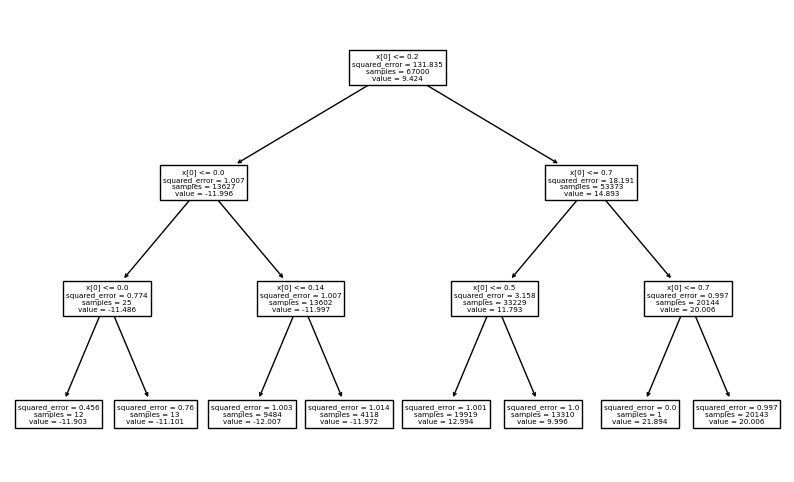

In [117]:
rt = tree.DecisionTreeRegressor(random_state=0, max_depth=3)
rt.fit(X_train,y_train)
_ = tree.plot_tree(rt)

In [128]:
n_nodes = rt.tree_.node_count
children_left = rt.tree_.children_left
children_right = rt.tree_.children_right
feature = rt.tree_.feature
threshold = rt.tree_.threshold
values = rt.tree_.value
impurities = rt.tree_.impurity
sample_size = rt.tree_.n_node_samples

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)
stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
ratios = -1*np.ones(shape=n_nodes)
pvals = -1*np.zeros(shape=n_nodes)

while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth

    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]

    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
        
        mse = impurities[node_id]
        mse_left = impurities[children_left[node_id]]
        mse_right = impurities[children_right[node_id]]

        n = sample_size[node_id]
        n_left = sample_size[children_left[node_id]]
        n_right = sample_size[children_right[node_id]]
        
        msep1 = (n_left + 1)*mse_left + (n_right + 1)*mse_right
        msep0 = (n + 1)*mse

        r = msep1/msep0

        ratios[node_id] = r

        # Calculate P-values here
        l_neg = -r*(n +1)/(n-1)
        l_left = (n_left + 1)/(n_left + 1) + l_neg
        l_right = (n_right + 1)/(n_right + 1) + l_neg
        
        p = chi_sq_cdf(0, [n_left - 1, n_right - 1, 1] , [l_left, l_right, l_neg])
        pvals[node_id] = p
    else:
        is_leaves[node_id] = True

ValueError: setting an array element with a sequence.

In [129]:
p

(nan, 0)

In [124]:
impurities

array([131.83453841,   1.00671841,   0.77443244,   0.45577736,
         0.76009733,   1.0066668 ,   1.00326038,   1.01363777,
        18.19057266,   3.1578092 ,   1.00100111,   1.00034473,
         0.99730448,   0.        ,   0.99717703])

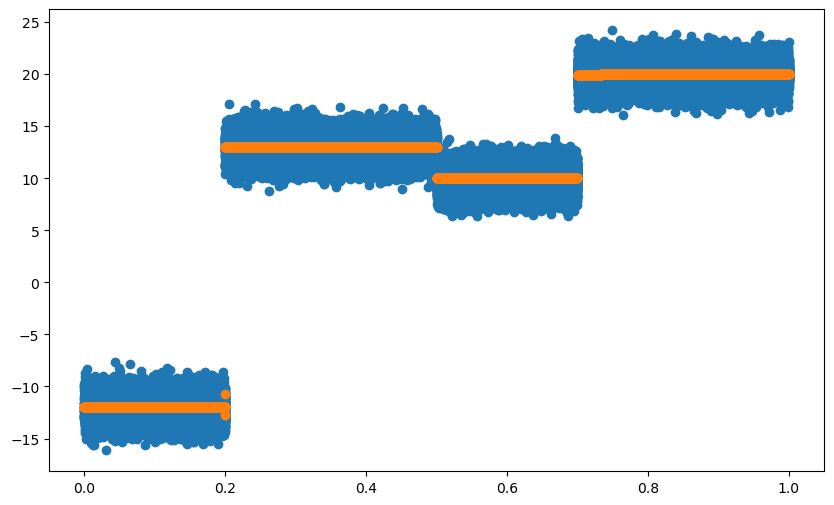

In [75]:
y_pred = rt.predict(X_test)
plt.scatter(X,y)
plt.scatter(X_test,y_pred)

In [56]:
path = rt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

Custom preprocessing before fitting the tree.
Custom postprocessing after fitting the tree.


In [ ]:
trees = []
for c in ccp_alphas[-4:]:
    clf = tree.DecisionTreeRegressor(random_state=0, ccp_alpha=c, max_depth=3)
    clf.fit(X_train, y_train)
    trees.append(clf)

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

In [ ]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
ax[2].plot(ccp_alphas, impurities[:-1], marker="o", drawstyle="steps-post")
ax[2].set_xlabel("effective alpha")
ax[2].set_ylabel("total impurity of leaves")
ax[2].set_title("Total Impurity vs effective alpha for training set")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

# Testing Z_r distribution

In [ ]:
n_a = 25
n_b = 30
n = n_a + n_b
r = 1

sample_size = 10000000

Z_a = np.random.chisquare(n_a - 1, size=sample_size)
Z_b = np.random.chisquare(n_b - 1,size=sample_size)
Z_neg = np.random.chisquare(1, size=sample_size)

l_neg = - r*(n+1)/(n-1)
l_a = (n_a + 1)/(n_a - 1) + l_neg
l_b = (n_b + 1)/(n_b - 1) + l_neg
l_neg = - r*(n+1)/(n-1)

Z_r =  l_a*Z_a + l_b*Z_b + l_neg*Z_neg

_= plt.hist(Z_r, bins = 50)

prob = np.sum(Z_r <=0)/sample_size
print(f"P(Z_r<=0) = {prob}")